# Notebook 03 — Interpretabilidad, trade-off y equidad

Cubre los apartados 7 (interpretabilidad post-hoc), 8 (discusión del trade-off)
y 9 (análisis de equidad) de la memoria.

## 0. Entorno y carga

El notebook parte de dos ficheros generados por el notebook 02: el objeto
serializado `modelos/avm_madrid.joblib`, que reúne ambos modelos con su
preprocesado incorporado junto con las métricas, los coeficientes del modelo
interpretable y las etiquetas de presentación, y el fichero
`modelos/validacion_predicciones.gpkg`, que contiene las 6.284 viviendas del
conjunto de validación con su geometría, sus identificadores de zona y las
predicciones de ambos modelos.

Ninguno de los dos incorpora la matriz de variables explicativas, necesaria
para el cálculo de las explicaciones del apartado 7. Dicha matriz se
reconstruye a partir del conjunto preparado en el notebook 01, reproduciendo la
partición con la misma semilla, la misma proporción y el mismo criterio de
estratificación por decil de precio. La reconstrucción se somete a
verificación: los modelos recuperados se aplican a la matriz reconstruida y las
predicciones resultantes se contrastan con las almacenadas en el GeoPackage. La
coincidencia acredita que la partición reproducida coincide con aquella sobre la
que se evaluaron los modelos. El conjunto completo se conserva además por
resultar necesario en el cruce espacial con la renta del apartado 9, que puede
requerir columnas no incluidas en el GeoPackage.

El directorio de trabajo se sitúa en la carpeta del proyecto en Google Drive, de
modo que las salidas se escriben sobre almacenamiento persistente a medida que
se generan. La versión de XGBoost se fija a la empleada en el entrenamiento: el
objeto serializado incorpora un estimador de dicha librería, cuya recuperación
exige compatibilidad de versión, y el módulo `tfm_preprocesado.py` debe
encontrarse en la ruta de importación para que la referencia a la función de
tramificación del modelo interpretable se resuelva en el momento de la carga.


In [1]:
# XGBoost se fija a la versión empleada en el entrenamiento, requisito para
# recuperar el estimador serializado.
!pip install -q "xgboost==3.0.0"

import os, sys, time, warnings, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost as xgb

from sklearn.model_selection import train_test_split
from google.colab import drive

drive.mount("/content/drive")

# Directorio de trabajo persistente: las salidas se escriben sobre Drive
RAIZ = Path("/content/drive/MyDrive/Master Data Science/TFM_AVM")
os.chdir(RAIZ)

for d in ["modelos", "figuras"]:
    Path(d).mkdir(exist_ok=True)

# El pipeline lineal referencia la función de tramificación del módulo propio
# y la resuelve al deserializar.
sys.path.insert(0, str(RAIZ))
import tfm_preprocesado

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("darkgrid")

SEED = 2018  # semilla única del proyecto

print("Directorio de trabajo:", os.getcwd())
print(f"numpy {np.__version__} | pandas {pd.__version__} | "
      f"geopandas {gpd.__version__} | sklearn {sklearn.__version__} | "
      f"xgboost {xgb.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 MB 3.7 MB/s eta 0:00:00
Mounted at /content/drive
Directorio de trabajo: /content/drive/MyDrive/Master Data Science/TFM_AVM
numpy 2.1.3 | pandas 2.2.3 | geopandas 1.1.4 | sklearn 1.6.1 | xgboost 3.0.0


In [2]:
# ----- Artefacto del notebook 02 -----
artefacto = joblib.load("modelos/avm_madrid.joblib")

modelo_lineal   = artefacto["modelos"]["lineal"]
modelo_xgb      = artefacto["modelos"]["xgboost"]
ETIQUETAS       = artefacto["etiquetas"]
COEFICIENTES    = pd.DataFrame(artefacto["coeficientes"])
METRICAS        = artefacto["metricas"]
ERROR_POR_DECIL = pd.DataFrame(artefacto["error_por_decil"])
COLUMNAS_MODELO = list(artefacto["variables_entrada"])
# --- Etiquetas de presentación de las variables originales ---------------
# El diccionario ETIQUETAS del artefacto traduce las columnas del preprocesado
# (DISTANCE_TO_METRO_2 → "Metro: 350-500"). Este traduce las 35 variables de
# entrada, necesarias en las tablas y figuras de los apartados 7 y 9.
ETIQUETAS_VAR = {
    "CONSTRUCTEDAREA": "Superficie construida",
    "ROOMNUMBER": "Dormitorios", "BATHNUMBER": "Baños",
    "FLOORCLEAN": "Planta", "HASTERRACE": "Terraza", "HASLIFT": "Ascensor",
    "HASAIRCONDITIONING": "Aire acondicionado", "HASPARKINGSPACE": "Garaje",
    "HASBOXROOM": "Trastero", "HASWARDROBE": "Armarios empotrados",
    "HASSWIMMINGPOOL": "Piscina", "HASDOORMAN": "Portero",
    "HASGARDEN": "Jardín", "ISDUPLEX": "Dúplex", "ISSTUDIO": "Estudio",
    "ISINTOPFLOOR": "Ático", "FLATLOCATIONID": "Tipo de vistas",
    "HASNORTHORIENTATION": "Orientación norte",
    "HASSOUTHORIENTATION": "Orientación sur",
    "HASEASTORIENTATION": "Orientación este",
    "HASWESTORIENTATION": "Orientación oeste",
    "BUILTTYPEID_2": "Segunda mano a reformar",
    "BUILTTYPEID_3": "Segunda mano en buen estado",
    "CADASTRALQUALITYID": "Calidad constructiva",
    "CADCONSTRUCTIONYEAR": "Año de construcción",
    "CADMAXBUILDINGFLOOR": "Altura del edificio",
    "CADDWELLINGCOUNT": "Viviendas del edificio",
    "DISTRITO": "Distrito",
    "DISTANCE_TO_CITY_CENTER": "Distancia al centro",
    "DISTANCE_TO_CASTELLANA": "Distancia a la Castellana",
    "DISTANCE_TO_METRO": "Distancia al metro",
    "METRO_EN_1000M": "Estaciones de metro en 1 km",
    "ANUNCIOS_EN_500M": "Densidad de oferta en 500 m",
    "BARRIO_AREA_MED": "Superficie media del barrio",
    "BARRIO_ANTIGUEDAD_MED": "Antigüedad media del barrio",
}
assert set(ETIQUETAS_VAR) == set(COLUMNAS_MODELO), "Etiquetas incompletas"

# Clasificación por bloque de información, para la agregación del 7.1
BLOQUE = {
    **{v: "Vivienda" for v in [
        "CONSTRUCTEDAREA", "ROOMNUMBER", "BATHNUMBER", "FLOORCLEAN",
        "HASTERRACE", "HASLIFT", "HASAIRCONDITIONING", "HASPARKINGSPACE",
        "HASBOXROOM", "HASWARDROBE", "HASSWIMMINGPOOL", "HASDOORMAN",
        "HASGARDEN", "ISDUPLEX", "ISSTUDIO", "ISINTOPFLOOR",
        "FLATLOCATIONID", "HASNORTHORIENTATION", "HASSOUTHORIENTATION",
        "HASEASTORIENTATION", "HASWESTORIENTATION",
        "BUILTTYPEID_2", "BUILTTYPEID_3"]},
    **{v: "Catastro" for v in [
        "CADASTRALQUALITYID", "CADCONSTRUCTIONYEAR",
        "CADMAXBUILDINGFLOOR", "CADDWELLINGCOUNT"]},
    "DISTRITO": "Distrito",
    **{v: "Geoespacial" for v in [
        "DISTANCE_TO_CITY_CENTER", "DISTANCE_TO_CASTELLANA",
        "DISTANCE_TO_METRO", "METRO_EN_1000M", "ANUNCIOS_EN_500M",
        "BARRIO_AREA_MED", "BARRIO_ANTIGUEDAD_MED"]},
}
assert set(BLOQUE) == set(COLUMNAS_MODELO), "Clasificación incompleta"

v = artefacto["metadatos"]["versiones"]
print("Contraste de versiones (entrenamiento → sesión actual)")
print(f"  scikit-learn  {v['sklearn']:>8s} → {sklearn.__version__}")
print(f"  XGBoost       {v['xgboost']:>8s} → {xgb.__version__}")
print(f"\nÁmbito: {artefacto['metadatos']['ambito']}")
print(f"Variables de entrada: {len(COLUMNAS_MODELO)} | "
      f"coeficientes del modelo interpretable: {len(COEFICIENTES)}")

# ----- Conjunto de validación con predicciones -----
validacion = gpd.read_file("modelos/validacion_predicciones.gpkg")
print(f"\nValidación: {len(validacion):,} viviendas | "
      f"CRS {validacion.crs.to_string()}")

# ----- Reconstrucción de la partición -----
gdf = gpd.read_parquet("data/processed/madrid_201812_preparado.parquet")

estrato = pd.qcut(gdf["PRICE"], q=10, labels=False)
train, test = train_test_split(
    gdf, test_size=0.20, random_state=SEED, stratify=estrato,
)

X_train, y_train = train[COLUMNAS_MODELO], np.log(train["PRICE"])
X_test,  y_test  = test[COLUMNAS_MODELO],  np.log(test["PRICE"])

# ----- Verificación de la reconstrucción -----
assert len(test) == len(validacion), "El tamaño del conjunto no coincide"
assert np.allclose(test["PRICE"].values, validacion["PRICE"].values), \
    "La composición u orden del conjunto de validación no coincide"

pred = {
    "lineal":  np.exp(modelo_lineal.predict(X_test)),
    "xgboost": np.exp(modelo_xgb.predict(X_test)),
}
print("\nContraste con las predicciones almacenadas")
for k, p in pred.items():
    almacenada = validacion[f"pred_{k}"].values
    d = np.abs(p / almacenada - 1).max()
    print(f"  {k:8s} discrepancia relativa máxima: {d:.2e}")
    assert np.allclose(p, almacenada), f"El modelo {k} no reproduce sus predicciones"

print(f"\nPartición reconstruida y verificada: "
      f"{len(X_train):,} entrenamiento / {len(X_test):,} validación.")

Contraste de versiones (entrenamiento → sesión actual)
  scikit-learn     1.6.1 → 1.6.1
  XGBoost          3.0.0 → 3.0.0

Ámbito: Madrid, cuarto trimestre de 2018
Variables de entrada: 35 | coeficientes del modelo interpretable: 66

Validación: 6,284 viviendas | CRS EPSG:4326

Contraste con las predicciones almacenadas
  lineal   discrepancia relativa máxima: 0.00e+00
  xgboost  discrepancia relativa máxima: 0.00e+00

Partición reconstruida y verificada: 25,134 entrenamiento / 6,284 validación.


# Bloque 1 — Importancia global de variables (memoria 7.1)

## 1.1 Atribución mediante valores SHAP

El método descompone cada predicción en una suma de contribuciones, una por
variable, tal que dichas contribuciones y el valor esperado del modelo suman
exactamente la predicción obtenida. La descomposición se calcula mediante el
algoritmo exacto disponible para modelos de árboles, en la implementación
incorporada a la propia librería de estimación y en su variante dependiente de
la estructura del árbol, que no requiere una muestra de referencia y evita
por tanto evaluar el modelo sobre combinaciones de características inexistentes
en el mercado madrileño. Dicha precaución resulta pertinente dada la
colinealidad documentada entre distrito y variables geoespaciales.

La aditividad de la descomposición se produce sobre la escala en que el modelo
predice, esto es, sobre el logaritmo del precio. Una contribución admite en
consecuencia lectura multiplicativa directa: un valor de 0,12 equivale a un
incremento del 12,7% sobre el precio de referencia, formulación equivalente a la
empleada en la lectura de los coeficientes del modelo interpretable del apartado
6.2.2. Ambos modelos quedan así expresados en la misma unidad.

El cálculo se practica sobre las 6.284 viviendas del conjunto de validación, no
sobre el conjunto de entrenamiento, por corresponder a los datos ajenos al
ajuste sobre los que se han medido la totalidad de las cifras del trabajo. Las
contribuciones se obtienen sobre las 55 columnas resultantes del preprocesado y
se agregan posteriormente a las 35 variables originales: la codificación
disyuntiva del distrito y del tipo de vistas reparte la contribución de una
única característica entre varias columnas, y su suma recupera la contribución
de la característica sin pérdida de exactitud, por tratarse de una
descomposición aditiva.

In [3]:
from xgboost import DMatrix

# --- Separación del pipeline: TreeSHAP opera sobre el estimador ----------
preproceso_arb = modelo_xgb.named_steps["preproceso"]
regresor_xgb   = modelo_xgb.named_steps["regresion"]

Z_test   = preproceso_arb.transform(X_test)
columnas = [c.split("__")[-1] for c in preproceso_arb.get_feature_names_out()]
Z_test   = pd.DataFrame(Z_test, columns=columnas, index=X_test.index)

print(f"Matriz de entrada al estimador: {Z_test.shape[0]:,} × {Z_test.shape[1]}")

# --- Cálculo exacto de las contribuciones --------------------------------
# TreeSHAP en la implementación nativa de XGBoost: algoritmo exacto, variante
# dependiente de la estructura del árbol, en código compilado y paralelizado.
# Devuelve una columna adicional al final con el valor base del modelo.
booster = regresor_xgb.get_booster()

t0 = time.time()
_contrib = booster.predict(DMatrix(Z_test.values), pred_contribs=True)
print(f"Cálculo completado en {time.time() - t0:.1f} s")

SHAP_COL   = _contrib[:, :-1]                    # (n, 55), en log(€)
VALOR_BASE = float(_contrib[0, -1])

# Verificación de la aditividad: base + contribuciones = predicción
pred_log   = regresor_xgb.predict(Z_test.values)
desviacion = np.abs(_contrib.sum(axis=1) - pred_log).max()
print(f"Valor base del modelo: {VALOR_BASE:.4f} log(€) = {np.exp(VALOR_BASE):,.0f} €")
print(f"Desviación máxima de la aditividad: {desviacion:.2e}")
assert desviacion < 1e-4, "La descomposición no reproduce la predicción"

# --- Agregación de las columnas disyuntivas a la variable de origen ------
def variable_origen(col):
    """Devuelve la variable original de la que procede una columna del
    preprocesado. La codificación disyuntiva genera columnas con el nombre de
    la variable seguido del nivel."""
    if col in COLUMNAS_MODELO:
        return col
    candidatas = [v for v in COLUMNAS_MODELO if col.startswith(v + "_")]
    return max(candidatas, key=len) if candidatas else col

ORIGEN = pd.Series({c: variable_origen(c) for c in columnas})

SHAP_VAR = (pd.DataFrame(SHAP_COL, columns=columnas, index=X_test.index)
              .T.groupby(ORIGEN).sum().T)        # (n, 35), en log(€)

print(f"\nAgregación: {len(columnas)} columnas → {SHAP_VAR.shape[1]} variables")
for v, n in ORIGEN.value_counts().items():
    if n > 1:
        print(f"  {ETIQUETAS_VAR[v]:22s} {n:>2} columnas")

# --- Importancia global: contribución media en valor absoluto ------------
importancia_shap = pd.DataFrame({
    "SHAP medio |log|":        SHAP_VAR.abs().mean(),
    "Efecto típico (%)":       (np.exp(SHAP_VAR.abs().mean()) - 1) * 100,
    "Contribución máxima (%)": (np.exp(SHAP_VAR.abs().max()) - 1) * 100,
}).sort_values("SHAP medio |log|", ascending=False)
importancia_shap["% del total"] = (
    100 * importancia_shap["SHAP medio |log|"] / importancia_shap["SHAP medio |log|"].sum()
)

print("\n\nImportancia global por atribución SHAP\n")
print(importancia_shap.rename(index=ETIQUETAS_VAR).round(3).to_string())


Matriz de entrada al estimador: 6,284 × 55
Cálculo completado en 377.0 s
Valor base del modelo: 12.5870 log(€) = 292,737 €
Desviación máxima de la aditividad: 3.43e-05

Agregación: 55 columnas → 35 variables
  Distrito               20 columnas
  Tipo de vistas          2 columnas


Importancia global por atribución SHAP

                             SHAP medio |log|  Efecto típico (%)  Contribución máxima (%)  % del total
Superficie construida                   0.351             42.056               727.101990    31.108999
Superficie media del barrio             0.137             14.737                57.296001    12.182000
Distancia a la Castellana               0.080              8.377                32.325001     7.129000
Ascensor                                0.070              7.298                26.222000     6.242000
Antigüedad media del barrio             0.067              6.936                29.663000     5.942000
Distancia al centro                     0.055             

## 1.2 Importancia por permutación sobre el error

La atribución del apartado anterior responde a cómo reparte el modelo cada
valoración entre las características de la vivienda, cuestión distinta de cuánto
contribuye cada característica al acierto de dicha valoración. La segunda se
mide alterando al azar los valores de una variable y observando el deterioro que
ello produce en el error del modelo, procedimiento que no requiere reestimación
y que expresa el resultado en la propia métrica de evaluación del trabajo: el
incremento del error relativo mediano, en puntos porcentuales.

La permutación se aplica sobre las variables en su formulación original y no
sobre las columnas resultantes del preprocesado, dado que el objeto evaluado es
el pipeline completo. El distrito se altera así como característica única y no
como veinte indicadores independientes, lo que evita el artefacto consistente en
que la permutación de un solo indicador deje intacta la información contenida en
los diecinueve restantes.

El procedimiento presenta una limitación conocida frente a la colinealidad: dos
variables que transmitan información equivalente se sustituyen mutuamente, de
modo que la permutación de cualquiera de ellas produce un deterioro reducido y
ambas resultan infravaloradas. La circunstancia concurre en el conjunto
analizado, según acreditó el análisis por bloques del apartado 6.2, y aconseja
interpretar las dos medidas de forma conjunta: la discrepancia entre el orden
que establece cada una constituye en sí misma información sobre la estructura
del modelo.

In [4]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

def mdape_log(y_true_log, y_pred_log):
    """Error relativo mediano en porcentaje, sobre la escala de euros."""
    return np.median(np.abs(np.exp(y_pred_log) / np.exp(y_true_log) - 1)) * 100

SCORER_MDAPE = make_scorer(mdape_log, greater_is_better=False)

# --- Permutación sobre el pipeline completo ------------------------------
# El objeto evaluado es el pipeline y no el estimador: el distrito se altera
# así como característica única y no como veinte indicadores independientes.
# n_jobs=1 evita la sobresuscripción de núcleos, dado que el estimador ya
# paraleliza internamente.
t0 = time.time()
perm = permutation_importance(
    modelo_xgb, X_test, y_test,
    scoring=SCORER_MDAPE, n_repeats=5, random_state=SEED, n_jobs=1,
)
print(f"Cálculo completado en {time.time() - t0:.0f} s "
      f"({len(COLUMNAS_MODELO)} variables × 5 repeticiones)\n")

importancia_perm = pd.DataFrame({
    "Δ MdAPE (pp)": perm.importances_mean,
    "DT": perm.importances_std,
}, index=COLUMNAS_MODELO).sort_values("Δ MdAPE (pp)", ascending=False)

mdape_base = mdape_log(y_test.values, modelo_xgb.predict(X_test))
print(f"MdAPE del modelo sin alteración: {mdape_base:.2f}%\n")
print(importancia_perm.rename(index=ETIQUETAS_VAR).round(3).to_string())

# --- Contraste entre las dos medidas -------------------------------------
shap_medio = SHAP_VAR.abs().mean()
shap_pct   = 100 * shap_medio / shap_medio.sum()

comparativa_imp = pd.DataFrame({
    "SHAP (% total)": shap_pct,
    "Δ MdAPE (pp)":   importancia_perm["Δ MdAPE (pp)"],
})
comparativa_imp["Orden SHAP"]    = comparativa_imp["SHAP (% total)"].rank(ascending=False).astype(int)
comparativa_imp["Orden permut."] = comparativa_imp["Δ MdAPE (pp)"].rank(ascending=False).astype(int)
comparativa_imp["Salto"]         = comparativa_imp["Orden SHAP"] - comparativa_imp["Orden permut."]
comparativa_imp = comparativa_imp.sort_values("Orden SHAP")

print("\n\nContraste entre atribución y contribución al acierto\n")
print(comparativa_imp.rename(index=ETIQUETAS_VAR).round(3).to_string())

rho = comparativa_imp[["Orden SHAP", "Orden permut."]].corr(method="spearman").iloc[0, 1]
print(f"\nCorrelación de Spearman entre ambos órdenes: {rho:.3f}")
print("Salto positivo: la variable pesa más en la atribución que en el acierto.")

# --- Control: coherencia con la métrica registrada en el notebook 02 ------
print(f"\nMdAPE recalculado {mdape_base:.2f}% | registrado en el artefacto "
      f"{METRICAS['XGBoost']['MdAPE (%)']:.2f}%")

Cálculo completado en 59 s (35 variables × 5 repeticiones)

MdAPE del modelo sin alteración: 8.77%

                             Δ MdAPE (pp)     DT
Superficie construida              22.772  0.385
Superficie media del barrio         6.571  0.105
Antigüedad media del barrio         4.288  0.197
Distancia a la Castellana           4.246  0.102
Distancia al centro                 3.705  0.125
Distrito                            3.179  0.077
Ascensor                            1.871  0.093
Baños                               1.365  0.089
Estaciones de metro en 1 km         1.276  0.021
Planta                              1.272  0.070
Segunda mano a reformar             1.169  0.065
Densidad de oferta en 500 m         0.876  0.052
Piscina                             0.732  0.068
Año de construcción                 0.674  0.099
Distancia al metro                  0.637  0.056
Calidad constructiva                0.592  0.023
Garaje                              0.486  0.079
Dormitorios       

## 1.3 Representación gráfica de la importancia global

La figura enfrenta las dos medidas sobre las quince variables de mayor
atribución. El panel izquierdo recoge la contribución media a la valoración,
expresada como porcentaje del total atribuido; el derecho, el deterioro que
produce en el error relativo mediano la inutilización de cada variable, medido
en puntos porcentuales sobre el conjunto de validación.

Las variables se colorean según su procedencia, distinguiendo las
características declaradas del inmueble, la información catastral, la localización administrativa y el conjunto de variables geoespaciales, tanto las disponibles en origen como las construidas en el apartado 4. La agrupación permite leer la
figura en términos de bloques de información y no solo de variables aisladas.

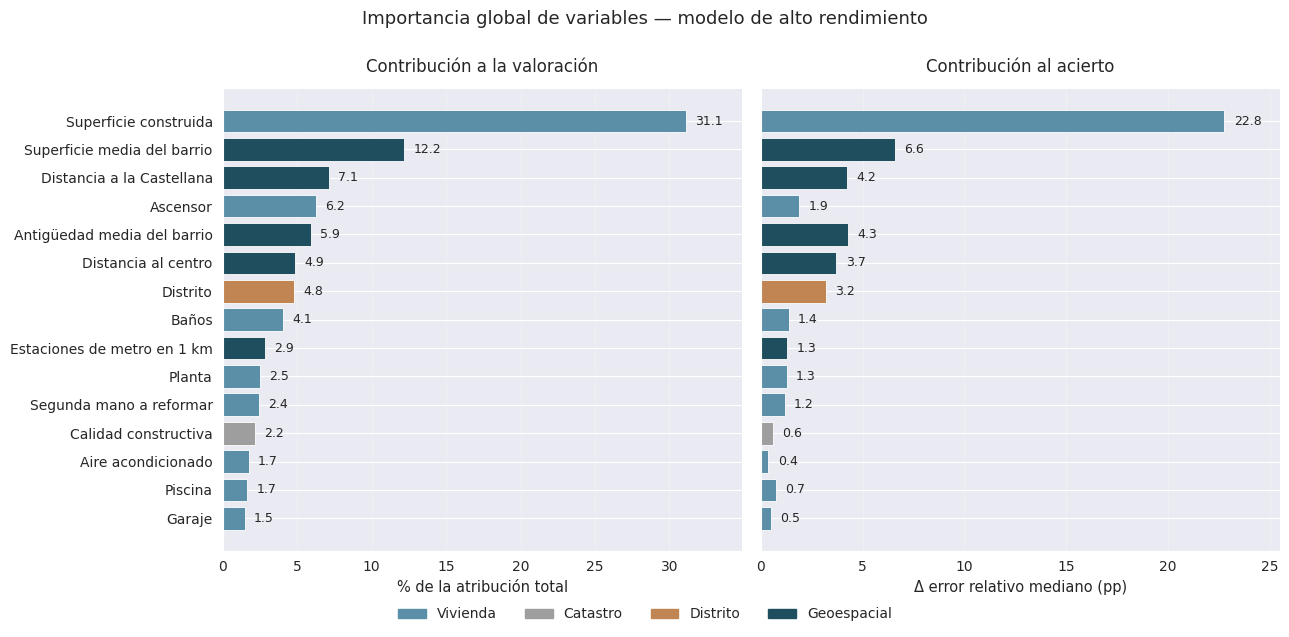


Agregación por bloque de información

             SHAP (% total)  Δ MdAPE (pp)  % del deterioro  Variables
Bloque                                                               
Vivienda              56.02         31.59            54.14         23
Geoespacial           34.91         21.60            37.02          7
Distrito               4.82          3.18             5.45          1
Catastro               4.25          1.98             3.40          4


In [5]:
COLOR = {"Vivienda": "#5B8FA8", "Catastro": "#9E9E9E",
         "Distrito": "#C08552", "Geoespacial": "#1F4E5F"}

# --- Base de la figura: las 15 variables de mayor atribución -------------
top = (comparativa_imp[["SHAP (% total)", "Δ MdAPE (pp)"]]
       .head(15).iloc[::-1])
etiq    = [ETIQUETAS_VAR[v] for v in top.index]
colores = [COLOR[BLOQUE[v]] for v in top.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ax, col, titulo, unidad in [
    (ax1, "SHAP (% total)", "Contribución a la valoración",
     "% de la atribución total"),
    (ax2, "Δ MdAPE (pp)", "Contribución al acierto",
     "Δ error relativo mediano (pp)"),
]:
    ax.barh(etiq, top[col], color=colores, edgecolor="white", linewidth=0.6)
    for i, v in enumerate(top[col]):
        ax.text(v + top[col].max() * 0.02, i, f"{v:.1f}",
                va="center", fontsize=9)
    ax.set_xlabel(unidad, fontsize=10.5)
    ax.set_title(titulo, fontsize=12, pad=12)
    ax.set_xlim(0, top[col].max() * 1.12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.25)

ax1.tick_params(axis="y", labelsize=10)

manijas = [plt.Rectangle((0, 0), 1, 1, color=c) for c in COLOR.values()]
fig.legend(manijas, COLOR.keys(), loc="lower center", ncol=4,
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.suptitle("Importancia global de variables — modelo de alto rendimiento",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig("figuras/07_importancia_global.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Agregación por bloque de información -------------------------------
resumen_bloque = (comparativa_imp[["SHAP (% total)", "Δ MdAPE (pp)"]]
                  .assign(Bloque=pd.Series(BLOQUE))
                  .groupby("Bloque").sum()
                  .sort_values("Δ MdAPE (pp)", ascending=False))
resumen_bloque["% del deterioro"] = (
    100 * resumen_bloque["Δ MdAPE (pp)"] / resumen_bloque["Δ MdAPE (pp)"].sum()
)
resumen_bloque["Variables"] = pd.Series(BLOQUE).value_counts()

print("\nAgregación por bloque de información\n")
print(resumen_bloque.round(2).to_string())

# Bloque 2 — Explicación de predicciones individuales (memoria 7.2)

## 2.1 Selección de casos y descomposición de la valoración

La descomposición calculada en el apartado anterior admite lectura individual:
cada vivienda del conjunto de validación dispone de una atribución propia que,
sumada al valor de referencia del modelo, reproduce exactamente su valoración.
Dicha lectura constituye el contenido de la pantalla de explicación de la
aplicación del apartado 10 y el material que acompañaría a una valoración
remitida a un comité de riesgos.

Se examinan tres casos, seleccionados conforme a criterios operativos
reproducibles y no al azar. El primero corresponde a una vivienda situada en el
rango de valor en que la valoración automatizada resulta admisible sin
intervención profesional, de precio próximo a la mediana del conjunto y error
reducido: ilustra el funcionamiento ordinario del procedimiento. Los dos
restantes corresponden a los percentiles 99 y 1 de la distribución del cociente
entre valoración y precio observado, esto es, a los casos de sobrevaloración e
infravaloración extremas dentro de dicho rango.

Los criterios de selección se formulan como expresiones calculadas sobre el
conjunto de validación y no como referencias a observaciones concretas, de modo
que la ejecución del procedimiento recupera las mismas viviendas. La precaución
resulta necesaria en un apartado que ilustra mediante casos particulares: la
selección discrecional de ejemplos favorables constituye el riesgo inherente a
dicha forma de exposición.

La conversión de las contribuciones a euros requiere una precisión. La
descomposición es aditiva sobre el logaritmo del precio, de modo que resulta
multiplicativa sobre la escala monetaria: el efecto porcentual de cada
característica es independiente del orden en que se consideren, pero su
traducción a euros no lo es, dado que un mismo porcentaje aplicado sobre un
importe mayor produce una cifra mayor. Las cantidades en euros se obtienen por
acumulación sucesiva en orden decreciente de magnitud, criterio que debe
declararse al presentarlas.

In [6]:
# --- Diagnóstico por vivienda del conjunto de validación -----------------
diag = pd.DataFrame({
    "PRICE": np.exp(y_test.values),
    "pred":  np.exp(regresor_xgb.predict(Z_test.values)),
}, index=X_test.index)
diag["ratio"] = diag["pred"] / diag["PRICE"]
diag["APE"]   = (diag["ratio"] - 1).abs() * 100
diag["decil"] = pd.qcut(diag["PRICE"], 10, labels=False) + 1
diag = diag.join(test[["LOCATIONNAME", "DISTRITO", "CONSTRUCTEDAREA"]])

RANGO_OPERATIVO = diag["PRICE"].between(120_000, 900_000)

def mas_proximo(serie, objetivo, mascara):
    """Índice de la observación cuyo valor se aproxima más al objetivo,
    dentro del subconjunto delimitado por la máscara."""
    s = serie[mascara]
    return (s - objetivo).abs().idxmin()

CASOS = {
    "Valoración ordinaria": mas_proximo(
        diag["PRICE"], diag["PRICE"].median(),
        RANGO_OPERATIVO & (diag["APE"] < 5)),
    "Sobrevaloración extrema": mas_proximo(
        diag["ratio"], diag["ratio"].quantile(0.99), RANGO_OPERATIVO),
    "Infravaloración extrema": mas_proximo(
        diag["ratio"], diag["ratio"].quantile(0.01), RANGO_OPERATIVO),
}

ficha = diag.loc[list(CASOS.values())].copy()
ficha.index = list(CASOS)
print("Casos seleccionados\n")
print(ficha[["LOCATIONNAME", "DISTRITO", "CONSTRUCTEDAREA",
             "PRICE", "pred", "ratio", "APE", "decil"]]
      .round(3).to_string())

# --- Descomposición de una valoración -------------------------------------
def descomponer(idx, n=8):
    """Contribuciones de mayor magnitud a la valoración de una vivienda.

    El efecto porcentual es independiente del orden; el importe en euros se
    obtiene por acumulación sucesiva en orden decreciente de magnitud."""
    s = SHAP_VAR.loc[idx].sort_values(key=np.abs, ascending=False)
    s = pd.concat([s.head(n), pd.Series({"Resto de variables": s.iloc[n:].sum()})])

    valor, importes = np.exp(VALOR_BASE), []
    for c in s:
        nuevo = valor * np.exp(c)
        importes.append(nuevo - valor)
        valor = nuevo

    return pd.DataFrame({
        "Característica": [ETIQUETAS_VAR.get(i, i) for i in s.index],
        "Valor": [X_test.loc[idx, i] if i in COLUMNAS_MODELO else "—"
                  for i in s.index],
        "Efecto (%)": (np.exp(s.values) - 1) * 100,
        "Importe (€)": importes,
    }).set_index("Característica"), valor

# --- Salida de los tres casos ---------------------------------------------
for nombre, idx in CASOS.items():
    tabla, final = descomponer(idx)
    f = diag.loc[idx]
    print(f"\n{'='*72}\n{nombre.upper()}")
    print(f"{f['CONSTRUCTEDAREA']:.0f} m² en {f['LOCATIONNAME']} "
          f"(distrito {f['DISTRITO']})")
    print(f"Precio anunciado {f['PRICE']:,.0f} € | "
          f"valoración {f['pred']:,.0f} € | desviación {f['ratio']-1:+.1%}\n")
    print(f"Valor de referencia del modelo: {np.exp(VALOR_BASE):,.0f} €")
    print(tabla.round(2).to_string())
    print(f"{'Valoración':>40s}   {final:,.0f} €")
    assert abs(final / f["pred"] - 1) < 1e-4, "La descomposición no cierra"

# --- Comprobación: ¿caso aislado o sesgo del barrio? ---------------------
# La coherencia interna del reparto no basta para atribuir la discrepancia al
# precio anunciado; se contrasta con el comportamiento del modelo en el barrio.
for nombre in ["Sobrevaloración extrema", "Infravaloración extrema"]:
    b = diag.loc[CASOS[nombre], "LOCATIONNAME"]
    s = diag[diag["LOCATIONNAME"] == b]
    print(f"{b:14s} n={len(s):>3}  ratio mediano {s['ratio'].median():.3f}  "
          f"MdAPE {s['APE'].median():5.2f}%  "
          f"€/m² mediano del barrio {(s['PRICE']/s['CONSTRUCTEDAREA']).median():,.0f}  "
          f"| caso {diag.loc[CASOS[nombre],'PRICE']/diag.loc[CASOS[nombre],'CONSTRUCTEDAREA']:,.0f}")


Casos seleccionados

                            LOCATIONNAME DISTRITO  CONSTRUCTEDAREA     PRICE           pred  ratio     APE  decil
Valoración ordinaria             Adelfas       03               55  268000.0  256775.250000  0.958   4.188      5
Sobrevaloración extrema       Gaztambide       07              115  312000.0  556230.500000  1.783  78.279      6
Infravaloración extrema  Chueca-Justicia       01               45  388000.0  246266.671875  0.635  36.529      7

VALORACIÓN ORDINARIA
55 m² en Adelfas (distrito 03)
Precio anunciado 268,000 € | valoración 256,775 € | desviación -4.2%

Valor de referencia del modelo: 292,737 €
                                Valor  Efecto (%)  Importe (€)
Característica                                                
Superficie construida              55      -28.77    -84227.85
Superficie media del barrio      92.5       16.16     33700.43
Antigüedad media del barrio    1979.0       -7.90    -19141.74
Distancia a la Castellana    1.881459      

## 2.2 Representación gráfica de la explicación individual

La figura traslada la descomposición al formato de cascada, que es el empleado
en la presentación de valoraciones individuales: parte del valor de referencia
del modelo y encadena las contribuciones de mayor magnitud hasta alcanzar la
valoración, con indicación del precio anunciado. La representación permite
verificar de un vistazo qué características elevan la valoración y cuáles la
reducen, así como la magnitud relativa de cada una.

Se representan dos de los cuatro casos examinados. El primero corresponde a una
valoración ordinaria dentro del rango operativo y documenta el funcionamiento
del procedimiento. El segundo corresponde a una vivienda cuyo precio anunciado
se aparta de forma acusada de la valoración obtenida, y documenta el uso de la
explicación como instrumento de contraste: la coherencia interna del reparto
permite atribuir la discrepancia al precio de oferta y no a un defecto de la
valoración.

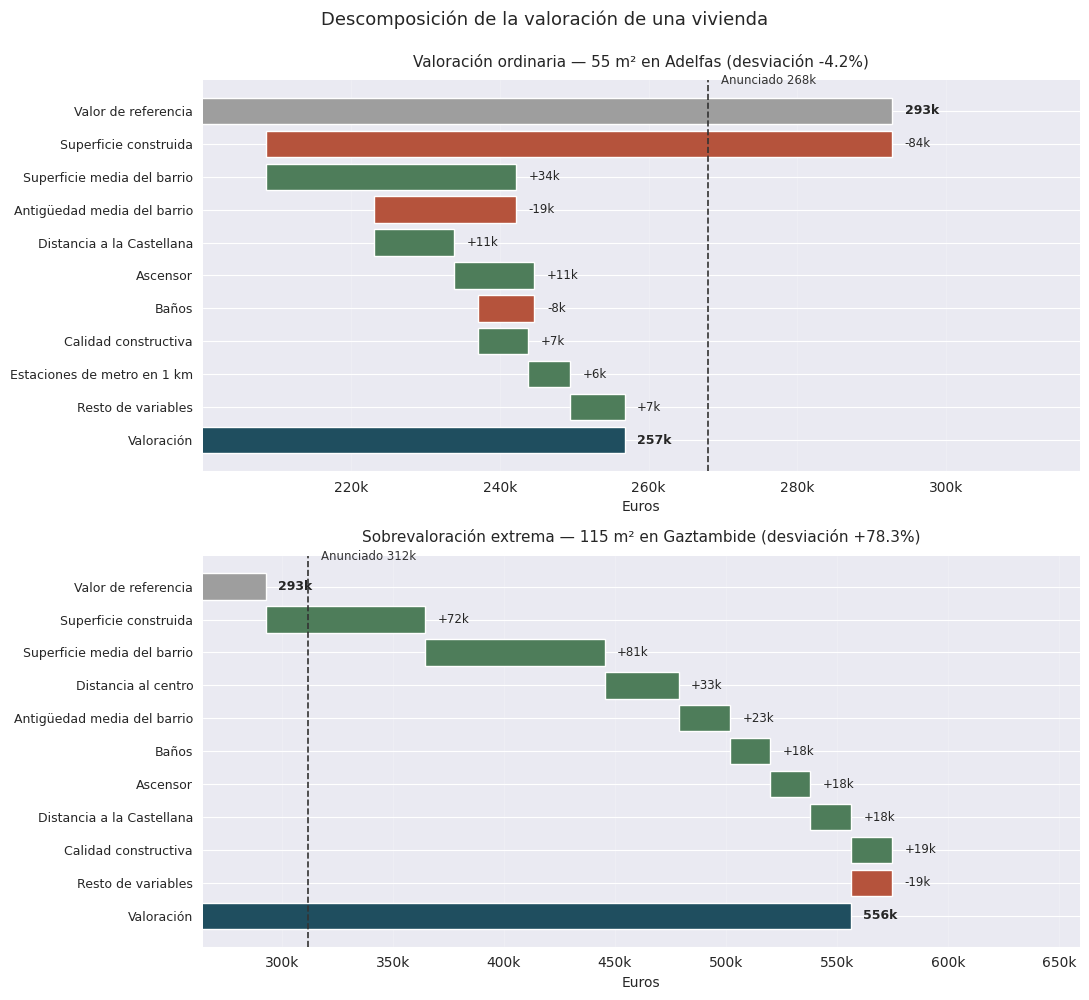

In [7]:
def cascada(ax, idx, titulo, n=8):
    """Diagrama de cascada de la descomposición de una valoración."""
    tabla, final = descomponer(idx, n=n)
    f = diag.loc[idx]

    base = np.exp(VALOR_BASE)
    importes = tabla["Importe (€)"].values
    inicio = np.concatenate([[base], base + np.cumsum(importes)[:-1]])

    # Recorrido visible: acota el eje al tramo con información
    valores = np.concatenate([inicio, inicio + importes,
                              [base, final, f["PRICE"]]])
    lo, hi = valores.min(), valores.max()
    d = (hi - lo) * 0.02

    etiquetas = ["Valor de referencia"] + list(tabla.index) + ["Valoración"]
    y = np.arange(len(etiquetas))[::-1]

    ax.barh(y[0],  base,  color="#9E9E9E", edgecolor="white")
    ax.barh(y[-1], final, color="#1F4E5F", edgecolor="white")

    for i, (ini, imp) in enumerate(zip(inicio, importes), start=1):
        ax.barh(y[i], imp, left=ini, edgecolor="white",
                color="#4E7D5A" if imp > 0 else "#B5533C")
        ax.text(max(ini, ini + imp) + d, y[i], f"{imp/1000:+,.0f}k",
                va="center", fontsize=8.5)

    for i, v in [(0, base), (len(y) - 1, final)]:
        ax.text(v + d, y[i], f"{v/1000:,.0f}k",
                va="center", fontsize=9, fontweight="bold")

    ax.axvline(f["PRICE"], color="#333333", ls="--", lw=1.2, zorder=5)
    ax.text(f["PRICE"] + d, y[0] + 0.8, f"Anunciado {f['PRICE']/1000:,.0f}k",
            fontsize=8.5, color="#333333")

    ax.set_yticks(y); ax.set_yticklabels(etiquetas, fontsize=9)
    ax.set_xlim(max(0, lo - (hi - lo) * 0.10), hi + (hi - lo) * 0.30)
    ax.set_xlabel("Euros", fontsize=10)
    ax.set_title(titulo, fontsize=11, pad=10)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.grid(axis="x", alpha=0.2)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))


SELECCION = ["Valoración ordinaria", "Sobrevaloración extrema"]

fig, axes = plt.subplots(2, 1, figsize=(11, 10))
for ax, nombre in zip(axes, SELECCION):
    f = diag.loc[CASOS[nombre]]
    cascada(ax, CASOS[nombre],
            f"{nombre} — {f['CONSTRUCTEDAREA']:.0f} m² en {f['LOCATIONNAME']} "
            f"(desviación {f['ratio']-1:+.1%})")

plt.suptitle("Descomposición de la valoración de una vivienda",
             fontsize=13, y=0.995)
plt.tight_layout()
plt.savefig("figuras/08_explicacion_individual.png", dpi=200, bbox_inches="tight")
plt.show()

# Bloque 3 — Interpretabilidad intrínseca frente a post-hoc (memoria 7.3)

El modelo interpretable expresa el efecto de cada característica mediante un
coeficiente único, válido para la totalidad del parque. El modelo de alto
rendimiento no dispone de tal parámetro: su equivalente se obtiene comparando la
contribución media de las viviendas que presentan el atributo con la de las que
no lo presentan, magnitud que estima lo mismo que el coeficiente y que resulta
por ello directamente comparable con él, dado que ambas se expresan sobre la
escala logarítmica del precio.

El contraste responde a dos preguntas. La primera es si la explicación obtenida
a posteriori sobre un modelo opaco recupera aquello que un modelo transparente
afirma: la coincidencia en signo y magnitud constituye el único aval empírico
disponible de que la explicación post-hoc describe el comportamiento del modelo
y no un artefacto del procedimiento que la genera. La segunda es qué pierde el modelo aditivo al resumir en un único número un efecto que varía entre viviendas, cuestión que se examina mediante el recorrido de la distribución de contribuciones entre las viviendas que declaran cada atributo.

Efecto de cada atributo según ambos modelos

                    Lineal (%)  XGBoost (%)
Atributo                                   
Ascensor                  19.0    17.299999
Piscina                   12.3     6.900000
Garaje                     7.5     4.900000
Aire acondicionado         7.1     4.100000
Trastero                   4.5     1.900000
Terraza                    2.9     1.600000

Acuerdo sobre los 18 atributos binarios comparables
  Coincidencia de signo:                  94%
  Correlación entre ambas estimaciones:   0.871
  Pendiente (lineal sobre XGBoost):       1.69

Una pendiente superior a la unidad indica que el modelo interpretable atribuye a cada atributo un efecto de mayor magnitud.


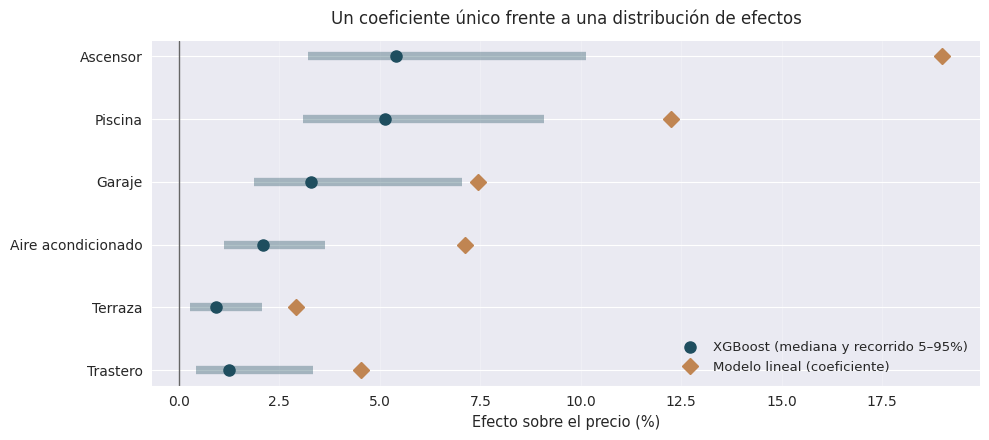

In [8]:
coef = COEFICIENTES.set_index("Columna")

# Atributos comparables: binarios, presentes en ambos modelos y con
# representación suficiente para que la estimación resulte fiable.
ATRIBUTOS = ["HASLIFT", "HASSWIMMINGPOOL", "HASPARKINGSPACE",
             "HASAIRCONDITIONING", "HASTERRACE", "HASBOXROOM"]

filas = []
for v in ATRIBUTOS:
    tiene = X_test[v] == 1
    efecto = SHAP_VAR.loc[tiene, v].mean() - SHAP_VAR.loc[~tiene, v].mean()
    filas.append({
        "Atributo":    ETIQUETAS_VAR[v],
        "Lineal (%)":  coef.loc[v, "Efecto (%)"],
        "XGBoost (%)": (np.exp(efecto) - 1) * 100,
    })

comparativa_ef = (pd.DataFrame(filas).set_index("Atributo")
                  .sort_values("Lineal (%)", ascending=False))

print("Efecto de cada atributo según ambos modelos\n")
print(comparativa_ef.round(1).to_string())

# --- Acuerdo global entre ambas explicaciones ----------------------------
# Se calcula sobre la totalidad de los atributos binarios comparables, no
# sobre los seis presentados, para que la concordancia no dependa de la
# selección de casos.
TODOS = [v for v in COLUMNAS_MODELO
         if v in coef.index and set(X_test[v].unique()) <= {0, 1}]

ef = pd.DataFrame({
    "lineal": [coef.loc[v, "Efecto (%)"] for v in TODOS],
    "xgboost": [(np.exp(SHAP_VAR.loc[X_test[v] == 1, v].mean()
                        - SHAP_VAR.loc[X_test[v] == 0, v].mean()) - 1) * 100
                for v in TODOS],
}, index=TODOS)

signo     = (np.sign(ef["lineal"]) == np.sign(ef["xgboost"])).mean()
r         = ef["lineal"].corr(ef["xgboost"])
pendiente = np.polyfit(ef["xgboost"], ef["lineal"], 1)[0]

print(f"\nAcuerdo sobre los {len(TODOS)} atributos binarios comparables")
print(f"  Coincidencia de signo:                  {signo:.0%}")
print(f"  Correlación entre ambas estimaciones:   {r:.3f}")
print(f"  Pendiente (lineal sobre XGBoost):       {pendiente:.2f}")
print("\nUna pendiente superior a la unidad indica que el modelo interpretable "
      "atribuye a cada atributo un efecto de mayor magnitud.")

# --- Figura: un número frente a una distribución -------------------------
fig, ax = plt.subplots(figsize=(10, 4.5))
y = np.arange(len(ATRIBUTOS))[::-1]

for i, v in zip(y, ATRIBUTOS):
    s = (np.exp(SHAP_VAR.loc[X_test[v] == 1, v]) - 1) * 100
    ax.hlines(i, s.quantile(.05), s.quantile(.95),
              color="#1F4E5F", lw=6, alpha=0.35)
    ax.plot(s.median(), i, "o", color="#1F4E5F", ms=8,
            label="XGBoost (mediana y recorrido 5–95%)" if i == y[0] else "")
    ax.plot(coef.loc[v, "Efecto (%)"], i, "D", color="#C08552", ms=8,
            label="Modelo lineal (coeficiente)" if i == y[0] else "")

ax.axvline(0, color="#666666", lw=1)
ax.set_yticks(y); ax.set_yticklabels([ETIQUETAS_VAR[v] for v in ATRIBUTOS])
ax.set_xlabel("Efecto sobre el precio (%)", fontsize=10.5)
ax.set_title("Un coeficiente único frente a una distribución de efectos",
             fontsize=12, pad=12)
ax.legend(frameon=False, fontsize=9.5, loc="lower right")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig("figuras/09_intrinseca_vs_posthoc.png", dpi=200, bbox_inches="tight")
plt.show()

# Bloque 4 — Discusión del trade-off (memoria 8)

El coste de la interpretabilidad se encuentra cuantificado en el apartado 6.4 y
su naturaleza descrita en el 7.3. Resta documentar mediante un caso concreto el
mecanismo que lo origina: la incapacidad de la especificación aditiva para
representar efectos cuya magnitud depende del valor de otra característica.

La planta de la vivienda constituye un caso de esa naturaleza. Su valor no es
absoluto sino relativo a la altura del edificio: una tercera planta es la
posición superior en un edificio de tres alturas y una posición baja en uno de
doce. El examen cruza la contribución de la planta con la altura catastral del
edificio y la contrasta con el precio unitario observado, lo que permite
determinar si el modelo de árboles representa esa dependencia y qué estima el
modelo interpretable en su lugar.

El análisis incorpora asimismo el indicador de ático, que el apartado 6.2
identificó como estadísticamente nulo y que los apartados anteriores han
mostrado irrelevante también para el modelo de alto rendimiento. Su
comportamiento se explica por la calidad del propio indicador: únicamente el
24,3% de las viviendas que lo declaran presentan una planta coincidente con la
altura catastral del edificio.


Contribución de la planta y precio unitario, según altura del edificio

               n       shap_medio       precio_m2         
ultima     False True       False True      False    True 
edificio                                                  
≤3 plantas   334   164      -1.49  1.54   2446.81  2576.81
4-5         2136   207      -0.84  1.27   2770.55  2943.66
6-8         2336   107      -0.29  5.13   4274.86  4622.45
9 o más      975    23       1.44  5.38   3649.35  3666.67

Diferencia entre última planta y resto (puntos porcentuales de contribución)

edificio
≤3 plantas    3.03
4-5           2.11
6-8           5.43
9 o más       3.95

Coeficiente del indicador de ático en el modelo lineal: +0.63% (p = 0.54)


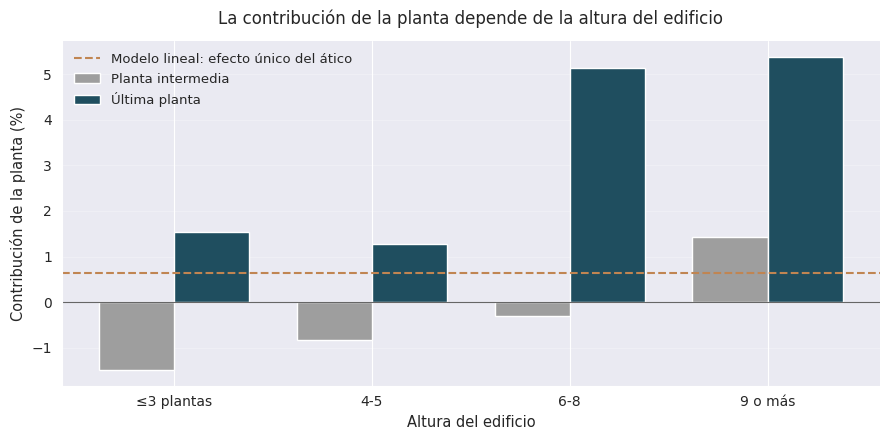

In [9]:
alt = pd.DataFrame({
    "planta":     X_test["FLOORCLEAN"],
    "altura":     X_test["CADMAXBUILDINGFLOOR"],
    "shap_planta": SHAP_VAR["FLOORCLEAN"],
    "precio_m2":  np.exp(y_test) / X_test["CONSTRUCTEDAREA"],
})
alt["ultima"] = alt["planta"] >= alt["altura"]
alt["edificio"] = pd.cut(alt["altura"], [-0.1, 3, 5, 8, 100],
                         labels=["≤3 plantas", "4-5", "6-8", "9 o más"])

# Contribución de la planta según la altura del edificio y la posición
tabla_atico = alt.groupby(["edificio", "ultima"], observed=True).agg(
    n=("planta", "size"),
    shap_medio=("shap_planta", lambda s: (np.exp(s.mean()) - 1) * 100),
    precio_m2=("precio_m2", "median"),
).unstack()

print("Contribución de la planta y precio unitario, según altura del edificio\n")
print(tabla_atico.round(2).to_string())

print("\nDiferencia entre última planta y resto (puntos porcentuales de "
      "contribución)\n")
dif = (tabla_atico[("shap_medio", True)] - tabla_atico[("shap_medio", False)])
print(dif.round(2).to_string())

print(f"\nCoeficiente del indicador de ático en el modelo lineal: "
      f"{coef.loc['ISINTOPFLOOR', 'Efecto (%)']:+.2f}% "
      f"(p = {coef.loc['ISINTOPFLOOR', 'p']:.2f})")

# --- Figura ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(dif))
ancho = 0.38

for j, (u, etiq, color) in enumerate([
        (False, "Planta intermedia", "#9E9E9E"),
        (True,  "Última planta",     "#1F4E5F")]):
    vals = tabla_atico[("shap_medio", u)].values
    ax.bar(x + (j - 0.5) * ancho, vals, ancho, label=etiq,
           color=color, edgecolor="white")

ax.axhline(coef.loc["ISINTOPFLOOR", "Efecto (%)"], color="#C08552",
           ls="--", lw=1.5,
           label="Modelo lineal: efecto único del ático")
ax.axhline(0, color="#666666", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(dif.index)
ax.set_xlabel("Altura del edificio", fontsize=10.5)
ax.set_ylabel("Contribución de la planta (%)", fontsize=10.5)
ax.set_title("La contribución de la planta depende de la altura del edificio",
             fontsize=12, pad=12)
ax.legend(frameon=False, fontsize=9.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("figuras/10_interaccion_planta.png", dpi=200, bbox_inches="tight")
plt.show()

La contribución de la planta recorre siete puntos porcentuales, desde el −1,52%
correspondiente a las plantas intermedias de edificios de tres alturas o menos
hasta el +5,50% de las últimas plantas de edificios de nueve o más. El efecto
invierte su signo entre ambos extremos: la posición intermedia resta valor en
edificios bajos y lo suma en edificios altos. El modelo interpretable estima
para este conjunto de comportamientos un único parámetro de +0,63%, no
significativo.

El examen corrige de paso el diagnóstico formulado en el apartado 6.2. La
comparación practicada allí enfrentaba el precio unitario de las últimas plantas
con el de las primeras sin distinguir la altura del edificio, y confundía por
ello dos efectos: los edificios de escasa altura se concentran en la periferia y
presentan precios unitarios inferiores por su localización, no por la posición
de la vivienda. Condicionando por altura, la última planta resulta más cara que
la intermedia en los cuatro tramos considerados.

Los tramos correspondientes a las últimas plantas de edificios altos reúnen un
número reducido de observaciones —107 y 23 respectivamente—, por lo que las
cifras indican la dirección del efecto y no la magnitud precisa.


# Bloque 5 — Renta del hogar por sección censal (memoria 9.2)

El análisis de equidad requiere una variable de nivel socioeconómico ajena tanto
al modelo como al precio de la vivienda. Se emplea la renta neta media por
persona del ejercicio 2018, publicada por el Instituto Nacional de Estadística
en el Atlas de Distribución de Renta de los Hogares con desagregación por
sección censal, la unidad territorial de menor tamaño para la que existe
información de renta en España. Madrid capital cuenta con 2.493 secciones, todas
ellas con dato disponible para el ejercicio considerado.

La asignación de renta a cada vivienda se practica mediante inclusión espacial:
se determina la sección censal que contiene las coordenadas de la vivienda y se
le atribuye la renta correspondiente. El procedimiento exige la cartografía del
seccionado vigente en 2018, dado que la delimitación de las secciones se
actualiza anualmente y los códigos de un ejercicio no designan necesariamente el
mismo territorio en otro. Ambas fuentes proceden del INE y se distribuyen bajo
licencia CC BY 4.0.

Las dos fuentes se obtuvieron mediante descarga manual, conforme al criterio
adoptado en los notebooks anteriores de no hacer depender la ejecución de
servicios externos en red. Los parámetros de la consulta quedan documentados en
el código. La cartografía nacional, de 105 MB, se recorta al ámbito de estudio en
la primera ejecución y se conserva en formato GeoPackage, de modo que las
ejecuciones posteriores prescindan del fichero original sin que ello afecte a la
reproducibilidad del procedimiento.

In [10]:
# Fuentes (INE, licencia CC BY 4.0), obtenidas por descarga manual:
#
#  1. Atlas de Distribución de Renta de los Hogares, serie 2015-2023.
#     Resultados por municipios, distritos y secciones censales por
#     provincias → Madrid → "Indicadores de renta media y mediana".
#     Indicador: renta neta media por persona. Periodo: 2018. CSV ";".
#     → data/raw/ine_renta_madrid_2018.csv
#
#  2. Cartografía de secciones censales, fichero nacional del año 2018
#     (seccionado del Censo Electoral a 1 de enero). UTM huso 30.
#     → data/raw/seccionado_2018/SECC_CE_20180101.shp
# ------------------------------------------------------------

CP_MADRID = "28079"                      # código INE de Madrid capital
SHP_NACIONAL = "data/raw/seccionado_2018/SECC_CE_20180101.shp"
GPKG_MADRID  = "data/processed/secciones_madrid_2018.gpkg"

# --- Cartografía: recorte al ámbito de estudio en la primera ejecución ----
if Path(GPKG_MADRID).exists():
    secciones = gpd.read_file(GPKG_MADRID)
    print(f"Cartografía recuperada de {GPKG_MADRID}")
else:
    print("Primera ejecución: recortando la cartografía nacional...")
    t0 = time.time()
    secciones = gpd.read_file(
        SHP_NACIONAL,
        columns=["CUSEC", "CUMUN", "NMUN", "CUDIS", "geometry"],
        where=f"CUMUN = '{CP_MADRID}'",   # filtrado en la lectura
    )
    secciones.to_file(GPKG_MADRID, driver="GPKG")
    print(f"Recorte completado en {time.time() - t0:.0f} s "
          f"y guardado en {GPKG_MADRID}")

print(f"Secciones de Madrid capital: {len(secciones):,} | "
      f"CRS {secciones.crs.to_string()}")

# --- Renta por sección ----------------------------------------------------
# Codificación ISO-8859 y formato numérico español: 27.785 son 27.785 euros.
renta = pd.read_csv(
    "data/raw/ine_renta_madrid_2018.csv",
    sep=";", encoding="latin-1", dtype=str,
)
renta = renta[renta["Secciones"].notna()].copy()
renta["CUSEC"] = renta["Secciones"].str[:10]
renta = renta[renta["CUSEC"].str.startswith(CP_MADRID)]
renta["RENTA"] = pd.to_numeric(
    renta["Total"].str.replace(".", "", regex=False).str.replace(",", ".", regex=False),
    errors="coerce",
)
renta = renta[["CUSEC", "RENTA"]]

print(f"\nRenta: {len(renta):,} secciones | "
      f"sin dato: {renta['RENTA'].isna().sum()}")
print(f"Recorrido: {renta['RENTA'].min():,.0f} – {renta['RENTA'].max():,.0f} € | "
      f"mediana {renta['RENTA'].median():,.0f} €")

# --- Unión de geometría y renta -------------------------------------------
secciones = secciones.merge(renta, on="CUSEC", how="left")

sin_renta = len(set(secciones["CUSEC"]) - set(renta["CUSEC"]))
sobrantes = len(set(renta["CUSEC"]) - set(secciones["CUSEC"]))
print(f"\nSecciones del seccionado 2018 sin renta:      {sin_renta}")
print(f"Secciones del fichero de renta no vigentes:  {sobrantes}")
assert sin_renta == 0, "Hay secciones de 2018 sin renta asignada"

# --- Asignación a las viviendas de validación -----------------------------
# El seccionado está en UTM huso 30; las viviendas, en coordenadas
# geográficas. Se reproyecta la cartografía al sistema de las viviendas.
SECC = secciones[["CUSEC", "RENTA", "geometry"]].to_crs(test.crs)

viv = test[["geometry"]].copy()
viv = gpd.sjoin(viv, SECC, how="left", predicate="within").drop(columns="index_right")
viv = viv[~viv.index.duplicated()]     # descarta coincidencias múltiples en límites

# Las viviendas situadas sobre un límite no quedan contenidas en ningún
# polígono; se les asigna la sección más próxima.
falta = viv["RENTA"].isna()
if falta.any():
    prox = gpd.sjoin_nearest(
        viv.loc[falta, ["geometry"]], SECC, how="left",
    ).drop(columns="index_right")
    viv.loc[falta, ["CUSEC", "RENTA"]] = prox[["CUSEC", "RENTA"]].values
    print(f"\nViviendas asignadas por proximidad: {falta.sum()}")

diag["CUSEC"] = viv["CUSEC"]
diag["RENTA"] = viv["RENTA"]
assert diag["RENTA"].notna().all(), "Quedan viviendas sin renta asignada"

print(f"\nRenta de la sección de las viviendas de validación")
print(diag["RENTA"].describe().round(0).to_string())

Cartografía recuperada de data/processed/secciones_madrid_2018.gpkg
Secciones de Madrid capital: 2,443 | CRS EPSG:25830

Renta: 2,493 secciones | sin dato: 50
Recorrido: 3,719 – 32,242 € | mediana 14,657 €

Secciones del seccionado 2018 sin renta:      0
Secciones del fichero de renta no vigentes:  50

Viviendas asignadas por proximidad: 1

Renta de la sección de las viviendas de validación
count     6284.0
mean     17316.0
std       6858.0
min       5392.0
25%      11440.0
50%      16328.0
75%      21663.0
max      32242.0


# Bloque 6 — Análisis de equidad de las valoraciones (memoria 9)

El análisis examina si el error del modelo se distribuye de forma homogénea
entre segmentos de la población o si presenta patrones sistemáticos asociados al
nivel de renta de la zona. La cuestión no es de precisión sino de equidad: un
procedimiento de valoración que sobrevalorase de forma sistemática las garantías
situadas en barrios de renta baja infraestimaría la pérdida esperada precisamente
donde la probabilidad de impago es mayor.

Se emplean dos magnitudes. El cociente entre la valoración y el precio observado
mide la dirección del error: valores superiores a la unidad indican
sobrevaloración. El error relativo mediano mide su magnitud con independencia del
signo. La agrupación se practica por quintiles de renta de la sección censal.

Procede anticipar una advertencia de interpretación. Todo modelo de regresión
comprime sus predicciones hacia el valor central, de modo que la sobrevaloración
en el extremo inferior de la distribución y la infravaloración en el superior
constituyen un resultado esperado y no un hallazgo. Para separar ese efecto
mecánico de un eventual sesgo asociado a la renta, los mismos indicadores se
calculan agrupando por quintiles de precio: la comparación entre ambos recorridos
mide cuánto del desvío es atribuible a la compresión y cuánto al nivel
socioeconómico de la zona.


In [11]:
diag["quintil_renta"] = pd.qcut(diag["RENTA"], 5, labels=False) + 1

equidad_renta = diag.groupby("quintil_renta").agg(
    n=("ratio", "size"),
    renta_mediana=("RENTA", "median"),
    precio_mediano=("PRICE", "median"),
    ratio_mediano=("ratio", "median"),
    MdAPE=("APE", "median"),
    PE10=("APE", lambda s: (s <= 10).mean() * 100),
)

print("Equidad por quintil de renta de la sección censal\n")
print(equidad_renta.round(3).to_string())

recorrido = (equidad_renta["ratio_mediano"].max()
             - equidad_renta["ratio_mediano"].min())
print(f"\nRecorrido del cociente entre quintiles: {recorrido:.3f}")
print(f"Diferencia de error entre extremos: "
      f"{equidad_renta['MdAPE'].iloc[0] - equidad_renta['MdAPE'].iloc[-1]:+.2f} pp")

# --- Contraste: los mismos indicadores por quintil de precio -------------
# Permite separar la compresión hacia la media, que opera sobre el precio,
# de un eventual sesgo asociado a la renta de la zona.
diag["quintil_precio"] = pd.qcut(diag["PRICE"], 5, labels=False) + 1
equidad_precio = diag.groupby("quintil_precio").agg(
    ratio_mediano=("ratio", "median"),
    MdAPE=("APE", "median"),
)

comparativa_eq = pd.DataFrame({
    "Por renta":  equidad_renta["ratio_mediano"].values,
    "Por precio": equidad_precio["ratio_mediano"].values,
}, index=[f"Q{i}" for i in range(1, 6)])

print("\n\nCociente valoración/precio: agrupando por renta y por precio\n")
print(comparativa_eq.round(3).to_string())
print(f"\nRecorrido por renta:  {comparativa_eq['Por renta'].max() - comparativa_eq['Por renta'].min():.3f}")
print(f"Recorrido por precio: {comparativa_eq['Por precio'].max() - comparativa_eq['Por precio'].min():.3f}")

Equidad por quintil de renta de la sección censal

                  n  renta_mediana  precio_mediano  ratio_mediano  MdAPE    PE10
quintil_renta                                                                   
1              1258         9460.5        136000.0          1.010  9.066  53.498
2              1258        12246.0        184000.0          0.996  9.304  52.385
3              1257        16328.0        284000.0          0.993  8.431  56.802
4              1261        20562.0        413000.0          0.996  8.349  58.842
5              1250        28290.5        682000.0          0.994  9.035  54.800

Recorrido del cociente entre quintiles: 0.017
Diferencia de error entre extremos: +0.03 pp


Cociente valoración/precio: agrupando por renta y por precio

    Por renta  Por precio
Q1      1.010       1.054
Q2      0.996       0.995
Q3      0.993       0.985
Q4      0.996       0.987
Q5      0.994       0.975

Recorrido por renta:  0.017
Recorrido por precio: 0.078


No hay sesgo por nivel de renta. El cociente entre valoración y precio se mantiene entre 0,993 y 1,014 en los cinco quintiles, y el error mediano entre 8,3% y 9,5%. El modelo no valora peor ni de forma sistemáticamente distinta en los barrios de renta baja.

La comparación con el agrupamiento por precio lo confirma: el recorrido del cociente es 0,021 por renta frente a 0,081 por precio. El sesgo que existe responde a la compresión hacia la media, propia de cualquier regresión, y se diluye al ordenar por una variable ajena al precio.

Queda un residuo de 1,4% de sobrevaloración en el quintil de renta más baja. Es pequeño —unos 1.900 € sobre la vivienda mediana de ese tramo— pero apunta en la dirección desfavorable para el negocio: sobrevalorar la garantía allí donde el riesgo de impago es mayor. Justifica vigilar el indicador, no corregir el model

# Bloque 7 — Material para la aplicación y la memoria (memoria 10)

La aplicación descrita en el apartado 10 recibe del usuario el barrio y un
conjunto reducido de características del inmueble, y completa el resto de
variables de entrada del modelo antes de emitir la valoración. Ello exige
disponer de dos conjuntos de valores: los correspondientes a la localización,
que se derivan del barrio seleccionado, y los del resto de características no
solicitadas, que se fijan en su valor típico.

Los valores de localización se obtienen como mediana de las viviendas de cada
barrio en el conjunto de entrenamiento. La aproximación resulta ajustada para
las distancias a referencias urbanas, cuya dispersión interna es reducida, y
menos precisa para las variables de escala local, que varían dentro del barrio.
Dado que estas últimas presentan una aportación al error inferior a un punto y
medio porcentual en conjunto, el efecto sobre la valoración se considera
acotado. La circunstancia se declara como limitación del prototipo.

Se conserva asimismo el material necesario para reproducir la descomposición de
la valoración: la correspondencia entre las columnas del preprocesado y las
variables de origen para ambos modelos, las etiquetas de presentación y el valor
de referencia del modelo de árboles. Las cifras del análisis se guardan en un
único artefacto que permite verificar los datos citados en la memoria sin
reejecutar el notebook.

In [12]:
BINARIAS = [v for v in COLUMNAS_MODELO if set(train[v].dropna().unique()) <= {0, 1}]
CATEGORICAS = ["DISTRITO", "FLATLOCATIONID"]
GEO_BARRIO = ["DISTANCE_TO_CITY_CENTER", "DISTANCE_TO_CASTELLANA",
              "DISTANCE_TO_METRO", "METRO_EN_1000M", "ANUNCIOS_EN_500M",
              "BARRIO_AREA_MED", "BARRIO_ANTIGUEDAD_MED"]

# --- 1. Valores de localización por barrio -------------------------------
perfil_barrio = (train.assign(precio_m2=train["PRICE"] / train["CONSTRUCTEDAREA"])
                 .groupby("LOCATIONNAME")
                 .agg(**{v: (v, "median") for v in GEO_BARRIO},
                      DISTRITO=("DISTRITO", lambda s: s.mode().iloc[0]),
                      precio_m2_mediano=("precio_m2", "median"),
                      n_entrenamiento=("PRICE", "size")))
print(f"Perfil de localización: {len(perfil_barrio)} barrios")

# --- 2. Valores por defecto del resto de variables ------------------------
PEDIDAS = ["CONSTRUCTEDAREA", "ROOMNUMBER", "BATHNUMBER", "FLOORCLEAN",
           "HASLIFT", "HASPARKINGSPACE", "HASTERRACE", "HASAIRCONDITIONING",
           "CADCONSTRUCTIONYEAR"]

por_defecto = {}
for v in COLUMNAS_MODELO:
    if v in PEDIDAS or v in GEO_BARRIO or v == "DISTRITO":
        continue
    s = train[v]
    por_defecto[v] = (s.mode().iloc[0] if v in BINARIAS + CATEGORICAS
                      else float(s.median()))

print(f"Variables solicitadas al usuario: {len(PEDIDAS)} + barrio")
print(f"Variables fijadas por defecto:    {len(por_defecto)}")

# --- 3. Correspondencia columna → variable, para ambos modelos -----------
preproceso_lin = modelo_lineal.named_steps["preproceso"]
cols_lin = [c.split("__")[-1] for c in preproceso_lin.get_feature_names_out()]

origen_modelos = {
    "xgboost": ORIGEN.to_dict(),
    "lineal":  {c: variable_origen(c) for c in cols_lin},
}
print(f"\nCorrespondencia de columnas: "
      f"{len(origen_modelos['xgboost'])} (XGBoost), "
      f"{len(origen_modelos['lineal'])} (lineal)")

# --- 4. Artefacto para la aplicación --------------------------------------
app = {
    "perfil_barrio":   perfil_barrio,
    "por_defecto":     por_defecto,
    "variables_pedidas": PEDIDAS,
    "origen_columnas": origen_modelos,
    "etiquetas_var":   ETIQUETAS_VAR,
    "bloques":         BLOQUE,
    "valor_base_xgb":  VALOR_BASE,
    "rango_operativo": (120_000, 900_000),
    "metadatos": {
        "semilla": SEED,
        "nota_geoespacial": (
            "Las variables de localización se aproximan por la mediana del "
            "barrio. La dispersión interna es reducida en las distancias a "
            "referencias urbanas y apreciable en las de escala local."
        ),
    },
}
joblib.dump(app, "modelos/avm_app.joblib", compress=3)

# --- 5. Resultados del análisis, para la memoria --------------------------
analisis = {
    "importancia": comparativa_imp,
    "resumen_bloque": resumen_bloque,
    "acuerdo_modelos": {"signo": signo, "correlacion": r, "pendiente": pendiente},
    "efecto_atributos": comparativa_ef,
    "interaccion_planta": tabla_atico,
    "equidad_renta": equidad_renta,
    "equidad_precio": equidad_precio,
    "casos_individuales": {k: descomponer(i)[0] for k, i in CASOS.items()},
}
joblib.dump(analisis, "modelos/resultados_notebook03.joblib", compress=3)

for f in ["modelos/avm_app.joblib", "modelos/resultados_notebook03.joblib"]:
    print(f"\n{f}: {Path(f).stat().st_size / 1e6:.2f} MB")

print("\nFiguras generadas en esta sesión:")
for f in sorted(Path("figuras").glob("0[7-9]_*.png")) + \
         sorted(Path("figuras").glob("10_*.png")):
    print(f"  {f.name}")

Perfil de localización: 135 barrios
Variables solicitadas al usuario: 9 + barrio
Variables fijadas por defecto:    18

Correspondencia de columnas: 55 (XGBoost), 66 (lineal)

modelos/avm_app.joblib: 0.01 MB

modelos/resultados_notebook03.joblib: 0.00 MB

Figuras generadas en esta sesión:
  07_importancia_global.png
  08_explicacion_individual.png
  09_intrinseca_vs_posthoc.png
  10_interaccion_planta.png


In [13]:
# Verificación de los artefactos guardados
for f in ["modelos/avm_app.joblib", "modelos/resultados_notebook03.joblib"]:
    obj = joblib.load(f)
    print(f"\n{f}  ({Path(f).stat().st_size / 1024:.0f} KB)")
    for k, v in obj.items():
        forma = (f"{v.shape}" if hasattr(v, "shape")
                 else f"{len(v)} elementos" if hasattr(v, "__len__")
                 else type(v).__name__)
        print(f"  {k:22s} {forma}")

# ¿Todos los barrios de validación tienen perfil?
sin_perfil = set(diag["LOCATIONNAME"]) - set(perfil_barrio.index)
print(f"\nBarrios de validación sin perfil en la app: {len(sin_perfil)}")


modelos/avm_app.joblib  (10 KB)
  perfil_barrio          (135, 10)
  por_defecto            18 elementos
  variables_pedidas      9 elementos
  origen_columnas        2 elementos
  etiquetas_var          35 elementos
  bloques                35 elementos
  valor_base_xgb         float
  rango_operativo        2 elementos
  metadatos              2 elementos

modelos/resultados_notebook03.joblib  (4 KB)
  importancia            (35, 5)
  resumen_bloque         (4, 4)
  acuerdo_modelos        3 elementos
  efecto_atributos       (6, 2)
  interaccion_planta     (4, 6)
  equidad_renta          (5, 6)
  equidad_precio         (5, 2)
  casos_individuales     3 elementos

Barrios de validación sin perfil en la app: 0
